In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

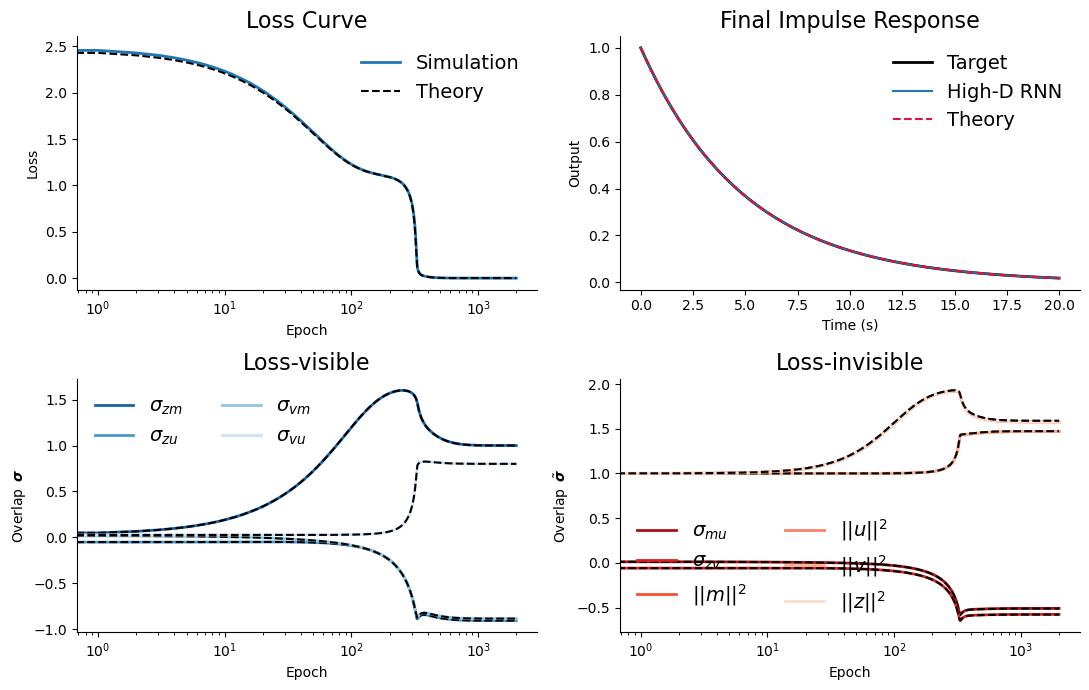

In [2]:
###################################
# --- 1. CONFIGURATION & TASK --- #
###################################
N, dt, t_max = 500, 0.025, 20
time_steps = int(t_max / dt)
lr, num_epochs = 5e-3, 2_000
target_a, target_c = 1.0, 0.2

t_axis = torch.linspace(0.0, t_max, time_steps)
y_target = target_a * torch.exp(-target_c * t_axis)

def normalize(x):
    return x / torch.norm(x, p=2)

##############################################
# --- 2. HIGH-DIMENSIONAL RNN SIMULATION --- #
##############################################
class low_rank_rnn(nn.Module):
    def __init__(self, N=100, scale=1, rank=1, phi='linear', dt=1.0, tau=1.0):
        super().__init__()
        self.N, self.dt, self.tau = N, dt, tau
        self.phi = lambda x: x
        
        self.m = nn.Parameter(scale * torch.randn(N, 1), requires_grad=True)
        self.u = nn.Parameter(scale * torch.randn(N, rank), requires_grad=True)
        self.v = nn.Parameter(scale * torch.randn(N, rank), requires_grad=True)
        self.z = nn.Parameter(scale * torch.randn(N, 1), requires_grad=True)

    def forward(self, x_t, h):
        W = (1.0 / self.N) * (self.u @ self.v.T)
        phi_h = self.phi(h)
        x_t = x_t.squeeze()
        h = h + (self.dt / self.tau) * (-h + W @ phi_h + self.m * x_t)
        y = (1.0 / self.N) * (self.z.T @ h)
        return y, h
                
class rnn_sim:
    def __init__(self):
        # Initialization
        self.rnn = low_rank_rnn(N=N, scale=1, rank=1, phi='linear', dt=dt, tau=1.0)
        m, u, v, z = [normalize(torch.randn(N, 1)) * np.sqrt(N) for _ in range(4)]
        with torch.no_grad():    
            self.rnn.m.copy_(m)
            self.rnn.u.copy_(u)
            self.rnn.v.copy_(v)
            self.rnn.z.copy_(z)
            
        self.optimizer = optim.SGD(self.rnn.parameters(), lr=N*lr)

    def train(self):
        history = {'loss': [], 'overlaps': []}
        for epoch in range(num_epochs):

            h = torch.zeros((self.rnn.N,1)) 
            x = torch.zeros((time_steps,1))
            x[0,0] = 1.0/dt     
                            
            y_hat = []                
            for t in range(time_steps):
                y_t, h = self.rnn(x[t,:], h)
                y_hat.append(y_t)   
                         
            loss = torch.sum((torch.stack(y_hat).squeeze() - y_target) ** 2) * dt
            history['loss'].append(loss.item())

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Record Overlaps
            m, u, v, z = self.rnn.m.flatten(), self.rnn.u.flatten(), self.rnn.v.flatten(), self.rnn.z.flatten()
            history['overlaps'].append([
                    (z @ m / N).item(), (z @ u / N).item(), (v @ m / N).item(), (v @ u / N).item(),  # "Visible"
                    (m @ u / N).item(), (z @ v / N).item(), (m @ m / N).item(), (u @ u / N).item(), (v @ v / N).item(), (z @ z / N).item() # "Invisible"
                 
            ])
        return history

###############################################
# --- 3. LOW-DIMENSIONAL THEORY (10D ODE) --- #
###############################################
class effective_rnn_from_scaler(nn.Module):
    def __init__(self, zm, zu, vm, vu, dt):
        super(effective_rnn_from_scaler, self).__init__()   
        
        self.dt = dt
        self._W_eff = torch.tensor([[0.0, 0.0], [0.0, 0.0]], requires_grad=False)
        self._z_eff = torch.tensor([[0.0], [0.0]], requires_grad=False)
        
        self.zm = nn.Parameter(torch.tensor(zm, dtype=torch.float32))
        self.zu = nn.Parameter(torch.tensor(zu, dtype=torch.float32))
        self.vm = nn.Parameter(torch.tensor(vm, dtype=torch.float32))
        self.vu = nn.Parameter(torch.tensor(vu, dtype=torch.float32))
        
    def forward(self, x_t, k):
        m_eff = torch.tensor([[1.], [0.]])
        W_eff = self._W_eff.clone()        
        z_eff = self._z_eff.clone()

        W_eff[1,0] = self.vm
        W_eff[1,1] = self.vu
        z_eff[0,0] = self.zm
        z_eff[1,0] = self.zu
        
        k_update = W_eff@k + m_eff@x_t.reshape(1, 1)
        k = k + self.dt * (-k + k_update)
        y = z_eff.T@k
        return y, k

def integrate_theory(initial_overlaps):
    """Integrates the 10 coupled ODEs describing overlap learning dynamics."""
    
    sig_zm, sig_zu, sig_vm, sig_vu, sig_mu, sig_zv, mm, uu, vv, zz = initial_overlaps
    history = {'loss': [], 'overlaps': []}
    
    for epoch in range(num_epochs):
        history['overlaps'].append((sig_zm, sig_zu, sig_vm, sig_vu, sig_mu, sig_zv, mm, uu, vv, zz))

        eff_rnn = effective_rnn_from_scaler(sig_zm, sig_zu, sig_vm, sig_vu, dt)
        optimizer  = torch.optim.SGD(eff_rnn.parameters(), lr=lr) 

        h = torch.zeros((2,1)) 
        x = torch.zeros((time_steps,1))
        x[0,0] = 1.0/dt     
                        
        y_hat = []                
        for t in range(time_steps):
            x_t = x[t,:]# .unsqueeze(0)
            y_t, h = eff_rnn(x_t, h)
            y_hat.append(y_t)  
    
        loss = torch.sum((torch.stack(y_hat).squeeze() - y_target) ** 2) * dt
        history['loss'].append(loss.item())

        optimizer.zero_grad()
        loss.backward()
    
        d_zm, d_zu = eff_rnn.zm.grad.item(),eff_rnn.zu.grad.item() 
        d_vm, d_vu = eff_rnn.vm.grad.item(),eff_rnn.vu.grad.item()
        
        scale = 1.0    
        sig_zm -= scale * lr * ( (mm + zz) * d_zm + sig_mu * d_zu + sig_zv * d_vm ) 
        sig_vm -= scale * lr * ( (mm + vv) * d_vm + sig_mu * d_vu + sig_zv * d_zm )
        sig_zu -= scale * lr * ( (uu + zz) * d_zu + sig_mu * d_zm + sig_zv * d_vu )
        sig_vu -= scale * lr * ( (uu + vv) * d_vu + sig_mu * d_vm + sig_zv * d_zu)
    
        sig_mu -= scale * lr * (sig_zm * d_zu + sig_vm * d_vu + sig_zu * d_zm + sig_vu * d_vm)
        sig_zv -= scale * lr * (sig_vm * d_zm + sig_vu * d_zu + sig_zm * d_vm + sig_zu * d_vu)
        
        mm -= scale * lr * 2 * (sig_zm * d_zm + sig_vm * d_vm)        
        uu -= scale * lr * 2 * (sig_zu * d_zu + sig_vu * d_vu)
        vv -= scale * lr * 2 * (sig_vm * d_vm + sig_vu * d_vu)
        zz -= scale * lr * 2 * (sig_zm * d_zm + sig_zu * d_zu)

    return history

#####################
# --- 4. TRAIN  --- #
#####################
sim = rnn_sim()
sim_res = sim.train()
the_res = integrate_theory(initial_overlaps=sim_res['overlaps'][0])

#######################
# --- 5. PLOTTING --- #
#######################
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten()
epochs_axis = np.arange(num_epochs)

# A. Loss Curve
ax[0].plot(sim_res['loss'], lw=2, label='Simulation')
ax[0].plot(the_res['loss'], '--k', label='Theory')
ax[0].set_title('Loss Curve', size=16)
ax[0].set_ylabel('Loss')
ax[0].legend(frameon=False, fontsize=14)

# B. Impulse Response
@torch.no_grad()
def run_rollout(model, x, h_init):
    """Generic rollout"""
    T, _ = x.shape
    h = h_init
    ys = []
    for t in range(T):
        y_t, h = model(x[t,:], h) 
        ys.append(y_t) 
    return torch.stack(ys).squeeze()

x = torch.zeros((time_steps, 1))
x[0,0] = 1.0/dt   

# High-D Rollout
y_highd = run_rollout(sim.rnn, x, h_init=torch.zeros(sim.rnn.N, 1))

# Effective Theory Rollout 
ovs = the_res['overlaps'][-1]
eff_rnn = effective_rnn_from_scaler(*ovs[:4], dt=dt) # Unpacks first 4 params
y_theory = run_rollout(eff_rnn, x, h_init=torch.zeros(2, 1))

highd_out  = y_highd.squeeze().numpy()
theory_out = y_theory.squeeze().numpy()

ax[1].plot(t_axis, y_target, color='k', lw=2, label='Target')
ax[1].plot(t_axis, highd_out, label='High-D RNN')
ax[1].plot(t_axis, theory_out, color='crimson', ls='--', label='Theory')
ax[1].set_title('Final Learned Funcation', size=16)

ax[1].set_title('Final Impulse Response', size=16)
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Output')
ax[1].legend(frameon=False, fontsize=14)

# C. Loss-Visible Overlaps
labels_v = [r'$\sigma_{zm}$', r'$\sigma_{zu}$', r'$\sigma_{vm}$', r'$\sigma_{vu}$']
ov_sim = np.array(sim_res['overlaps'])
ov_th = np.array(the_res['overlaps'])
cols = sns.color_palette('Blues_r', n_colors=4)
for i in range(4):
    ax[2].plot(epochs_axis, ov_sim[:, i], lw=2, label=labels_v[i], color=cols[i],)
    ax[2].plot(epochs_axis, ov_th[:, i], '--k')
ax[2].set_title('Loss-visible', size=16)
ax[2].set_ylabel(r'$\text{Overlap}\,\,\, \boldsymbol{\sigma}$')
ax[2].legend(ncol=2, frameon=False, fontsize=14)

# D. Loss-Invisible Overlaps
labels_inv = [r'$\sigma_{mu}$', r'$\sigma_{zv}$', r'$||m||^2$', r'$||u||^2$', r'$||v||^2$', r'$||z||^2$']
cols = sns.color_palette('Reds_r', n_colors=6)
for i in range(4, 10):
    ax[3].plot(epochs_axis, ov_sim[:, i], lw=2, label=labels_inv[i-4], color=cols[i-4])
    ax[3].plot(epochs_axis, ov_th[:, i], '--k')
ax[3].set_title('Loss-invisible', size=16)
ax[3].set_ylabel(r'$\text{Overlap}\,\,\, \tilde{\boldsymbol{\sigma}}$')
ax[3].legend(ncol=2, frameon=False, fontsize=14)

for a in [ax[0],ax[2],ax[3]]:
    a.set_xlabel('Epoch')
    a.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.show()